In [1]:
import pandas as pd
import numpy as np
from fmannot.query.alphagenome import read_tracks_for_variant
from fmannot.plotting import plot_track
from fmannot.data_utils import load_gtf
from alphagenome.models import variant_scorers
import seaborn as sns
import matplotlib.pyplot as plt

# set up scoring filters

In [2]:
best_scorers = [
    'ATAC',
    'CONTACT_MAPS',
    'DNASE',
    'CHIP_TF',
    'CHIP_HISTONE',
    'CAGE',
    'PROCAP',
    'RNA_SEQ',
    'SPLICE_SITES',
    'SPLICE_SITE_USAGE',
    'SPLICE_JUNCTIONS',
    'POLYADENYLATION'
]

scorers_to_keep = [str(variant_scorers.RECOMMENDED_VARIANT_SCORERS.get(s, None)) for s in best_scorers]

# read in effect prediction data

In [4]:
df = (pd
    .read_feather('../out/effect_predictions.feather')
    .query('variant_scorer in @scorers_to_keep')
    .assign(abs_quantile_score = lambda x: x['quantile_score'].abs())
)

In [5]:
df.head()

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,output_type,variant_scorer,track_name,assay_title,...,maf,OR,95_CI,Meta_P,I2_Pf,category,description,high_level_annotation,low_level_annotation,abs_quantile_score
0,chr1:207629207:A>C,chr1:207104919-208153495:.,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000084 ATAC-seq,ATAC-seq,...,0.187,1.17,1.13–1.21,3.6 __10_24,"0, 8 __10_1",known,"T-lymphocyte, an adaptive immune cell",Immune System,immune_cell,0.881915
1,chr1:207629207:A>C,chr1:207104919-208153495:.,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000100 ATAC-seq,ATAC-seq,...,0.187,1.17,1.13–1.21,3.6 __10_24,"0, 8 __10_1",known,Neuron that controls muscle movement,Brain,brain_cell,0.843837
2,chr1:207629207:A>C,chr1:207104919-208153495:.,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000236 ATAC-seq,ATAC-seq,...,0.187,1.17,1.13–1.21,3.6 __10_24,"0, 8 __10_1",known,"B-lymphocyte, an adaptive immune cell",Immune System,immune_cell,0.879325
3,chr1:207629207:A>C,chr1:207104919-208153495:.,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000623 ATAC-seq,ATAC-seq,...,0.187,1.17,1.13–1.21,3.6 __10_24,"0, 8 __10_1",known,"NK cell, an innate immune cell",Immune System,immune_cell,0.949106
4,chr1:207629207:A>C,chr1:207104919-208153495:.,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000624 ATAC-seq,ATAC-seq,...,0.187,1.17,1.13–1.21,3.6 __10_24,"0, 8 __10_1",known,Helper T-cell subtype,Immune System,immune_cell,0.862638


In [6]:
df.columns.values

array(['variant_id', 'scored_interval', 'gene_id', 'gene_name',
       'gene_type', 'gene_strand', 'output_type', 'variant_scorer',
       'track_name', 'assay_title', 'ontology_curie', 'biosample_name',
       'biosample_type', 'raw_score', 'quantile_score', 'variant', 'chr',
       'position_grch37', 'position_grch38', 'closest_gene', 'ref', 'alt',
       'major', 'minor', 'maf', 'OR', '95_CI', 'Meta_P', 'I2_Pf',
       'category', 'description', 'high_level_annotation',
       'low_level_annotation', 'abs_quantile_score'], dtype=object)

In [7]:
df.shape

(496784, 34)

In [8]:
# get idx of max abs score for each (variant, output_type) group
idx_max_abs = df.groupby(['variant', 'output_type'])['abs_quantile_score'].idxmax()

# get peak impact rows and pivot for heatmap
df_wide_matrix = (
    df
    .loc[idx_max_abs]
    .assign(snp_gene = lambda x: x['variant'] + '\n(' + x['closest_gene'] + ')')
    .pivot(
        index='snp_gene',
        columns='output_type',
        values='quantile_score'
    )
    .fillna(0) # set scores with missing values to have impact of 0.
).T

In [9]:
df_wide_matrix

snp_gene,rs10808026\n(EPHA1),rs10933431\n(INPP5D),rs11218343\n(SORL1),rs12539172\n(NYAP1),rs12881735\n(SLC24A4),rs138190086\n(ACE),rs17125924\n(FERMT2),rs3740688\n(SPI1),rs3752246\n(ABCA7),rs3851179\n(PICALM),...,rs6024870\n(CASS4),rs6733839\n(BIN1),rs73223431\n(PTK2B),rs7412\n(APOE),rs75932628\n(TREM2),rs7920721\n(ECHDC3),rs7933202\n(MS4A2),rs9271058\n(HLA-DRB1),rs9331896\n(CLU),rs9473117\n(CD2AP)
output_type,,,,,,,,,,,,,,,,,,,,,
ATAC,0.900830,-0.959379,0.896390,-0.992509,-0.692978,-0.953488,0.591924,-0.923901,0.907154,0.978005,...,0.963724,0.991597,-0.966869,0.891761,-0.989902,0.994694,0.985756,0.991597,0.962044,0.996494
CAGE,0.902982,0.978501,0.920450,-0.994183,-0.896390,0.994048,-0.889375,0.957501,0.979461,0.962044,...,-0.992335,0.992156,-0.972998,0.930376,-0.991974,0.995881,0.969051,0.990355,0.972998,0.989667
CHIP_HISTONE,-0.914991,-0.980378,0.946766,0.997684,0.907154,0.960287,0.939103,-0.997402,0.985088,0.964537,...,-0.994571,0.996067,0.946766,-0.988142,-0.986394,-0.997839,-0.988674,0.988931,0.995587,0.998573
CHIP_TF,-0.911155,0.962893,0.896390,-0.996067,-0.898633,-0.891761,0.992845,-0.999867,0.958450,0.987867,...,0.996067,0.995484,-0.971090,0.984028,-0.982893,0.998074,-0.992335,0.987298,0.981678,0.995161
CONTACT_MAPS,0.671556,0.817527,0.788366,0.893082,0.465447,0.738510,0.681652,0.961097,0.949316,0.482703,...,0.992544,0.994071,0.968159,0.747322,0.827626,0.997941,0.883945,0.881557,0.895266,0.876654
DNASE,0.868425,0.961175,0.928809,-0.988931,0.923901,-0.879325,0.992156,-0.958450,0.940451,0.982893,...,0.946766,0.988674,-0.976447,0.865561,-0.986078,0.995048,0.984028,0.994571,0.994048,0.998605
PROCAP,0.830022,0.889375,0.896390,-0.993622,0.322598,-0.907154,0.881915,0.737944,-0.894099,0.966869,...,-0.990997,-0.868425,0.879325,-0.865561,-0.975349,-0.987586,-0.975349,0.876682,0.947949,0.939103
RNA_SEQ,0.998605,0.997630,0.996156,0.999977,0.989182,0.999817,-0.997630,0.999471,0.998840,-0.996413,...,-0.999179,0.999681,0.998029,0.999539,-0.999937,0.999934,-0.999844,-0.998943,0.999378,-0.997016
SPLICE_JUNCTIONS,0.950415,0.979689,0.968863,0.984525,0.940957,0.000000,0.972779,0.988489,0.996423,0.000000,...,0.981447,0.000000,0.980588,0.986499,0.986499,0.000000,0.000000,0.000000,0.999102,0.000000


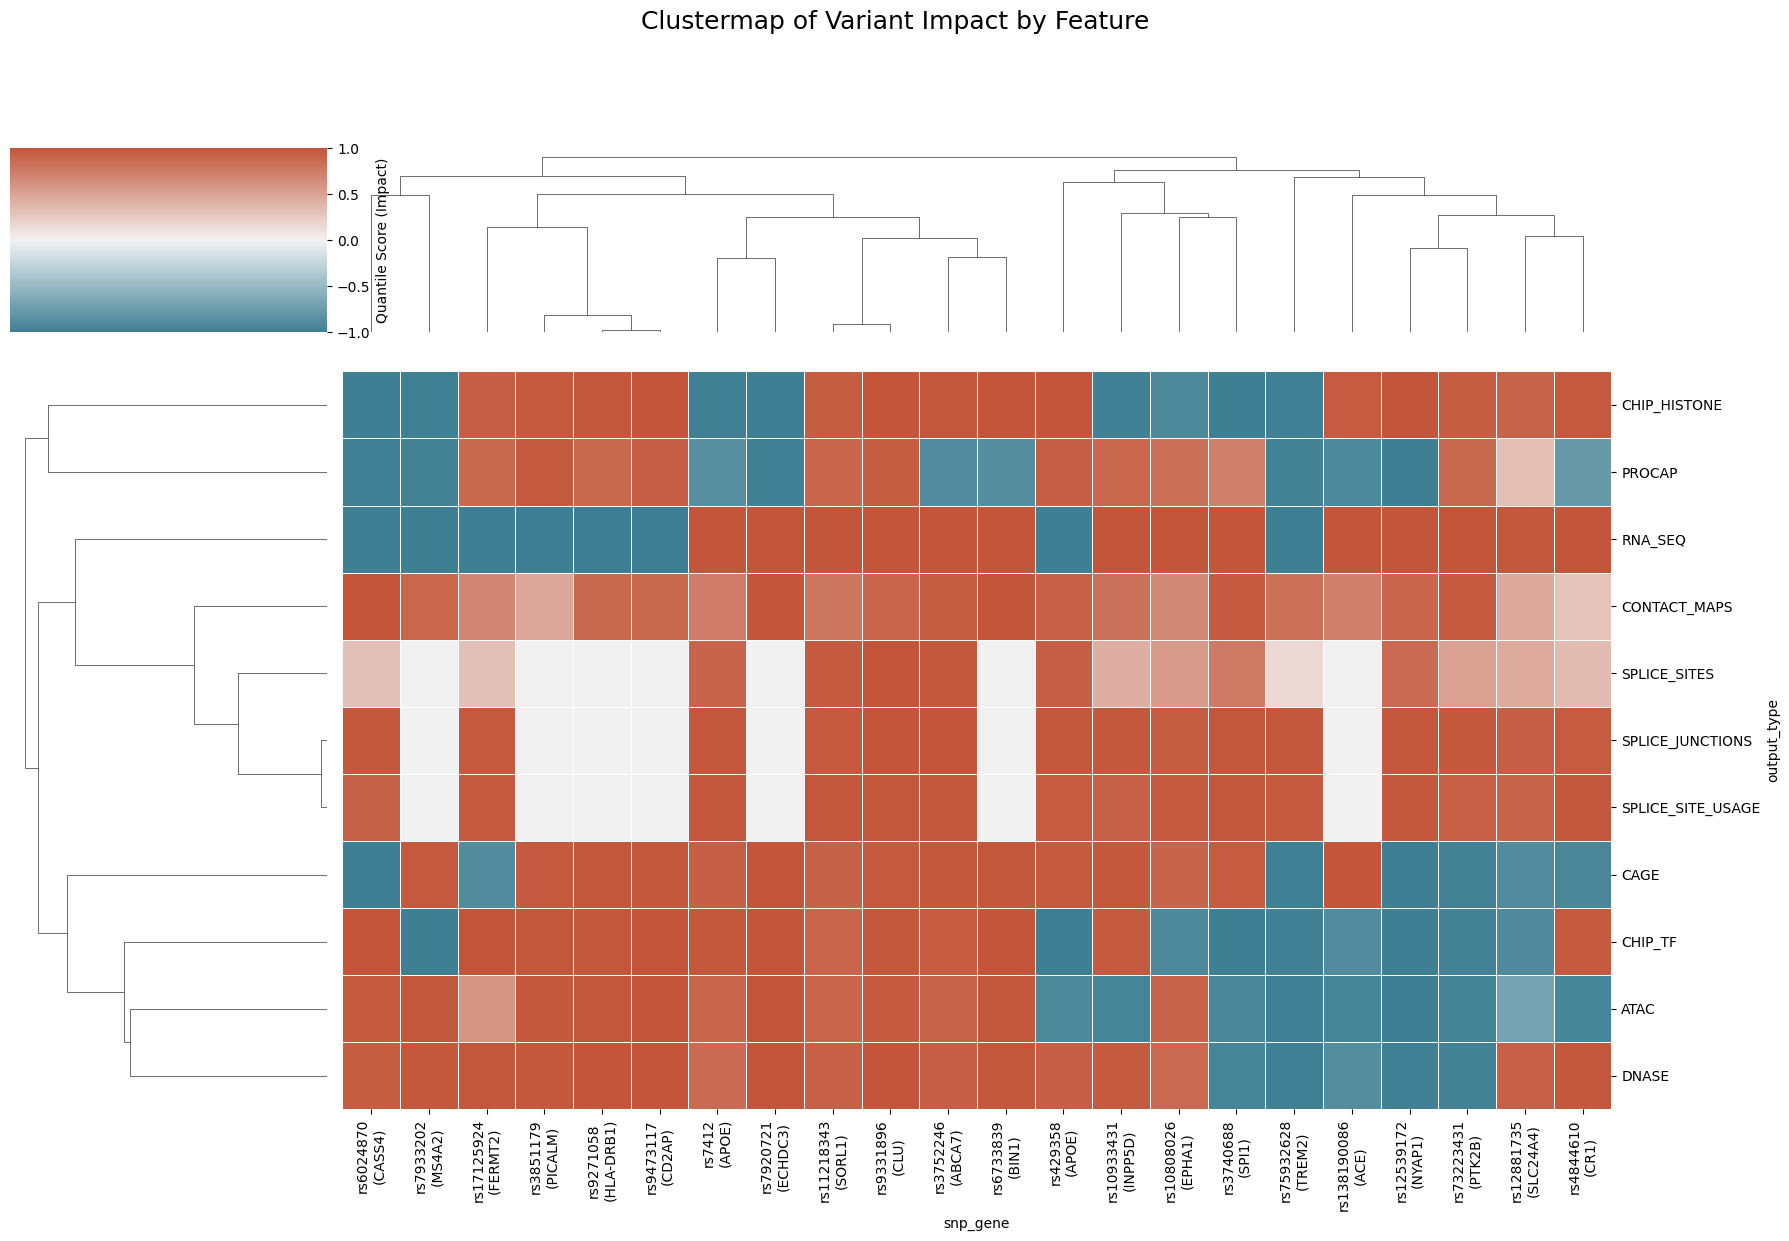

In [10]:
g = sns.clustermap(
    df_wide_matrix,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1.0,
    vmax=1.0,
    center=0.0,
    standard_scale=None,
    z_score=None,
    figsize=(18, 12),   # Give the plot plenty of space
    linewidths=0.5,    # Add thin white lines between cells
    linecolor='white',
    cbar_kws={'label': 'Quantile Score (Impact)'},
    xticklabels=True,
    yticklabels=True
)

g.fig.suptitle('Clustermap of Variant Impact by Feature', fontsize=18, y=1.03)
g.fig.tight_layout(rect=[0, 0, 1, 0.96])

# load track predictions for a snp

In [11]:
variant, ref_track_data, alt_track_data = read_tracks_for_variant(
    'rs4844610', store_path='../out/track_predictions.zarr')

Successfully found string for rs4844610:
chr1_207629207_A_C
Successfully loaded: TrackData(values=<Array file://../out/track_predictions.zarr/rs4844610/RNA_SEQ/REFERENCE/values shape=(1048576, 6) dtype=float32>, metadata=                            name strand         Assay title ontology_curie  \
0  CL:0000084 polyA plus RNA-seq      +  polyA plus RNA-seq     CL:0000084   
1       CL:0000084 total RNA-seq      +       total RNA-seq     CL:0000084   
2      EFO:0001200 total RNA-seq      +       total RNA-seq    EFO:0001200   
3  CL:0000084 polyA plus RNA-seq      -  polyA plus RNA-seq     CL:0000084   
4       CL:0000084 total RNA-seq      -       total RNA-seq     CL:0000084   
5      EFO:0001200 total RNA-seq      -       total RNA-seq    EFO:0001200   

  biosample_name biosample_type biosample_life_stage gtex_tissue data_source  \
0         T-cell   primary_cell                adult                  encode   
1         T-cell   primary_cell                adult                  en

/Users/seafloor/Library/CloudStorage/OneDrive-CardiffUniversity/postdoc/papers/fmannot/src/fmannot/query/alphagenome.py:280: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  metadata = pd.read_json(attrs['metadata_json'], orient='records')
/Users/seafloor/Library/CloudStorage/OneDrive-CardiffUniversity/postdoc/papers/fmannot/src/fmannot/query/alphagenome.py:280: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  metadata = pd.read_json(attrs['metadata_json'], orient='records')


In [12]:
gtf, gtf_transcripts, transcript_extractor = load_gtf()

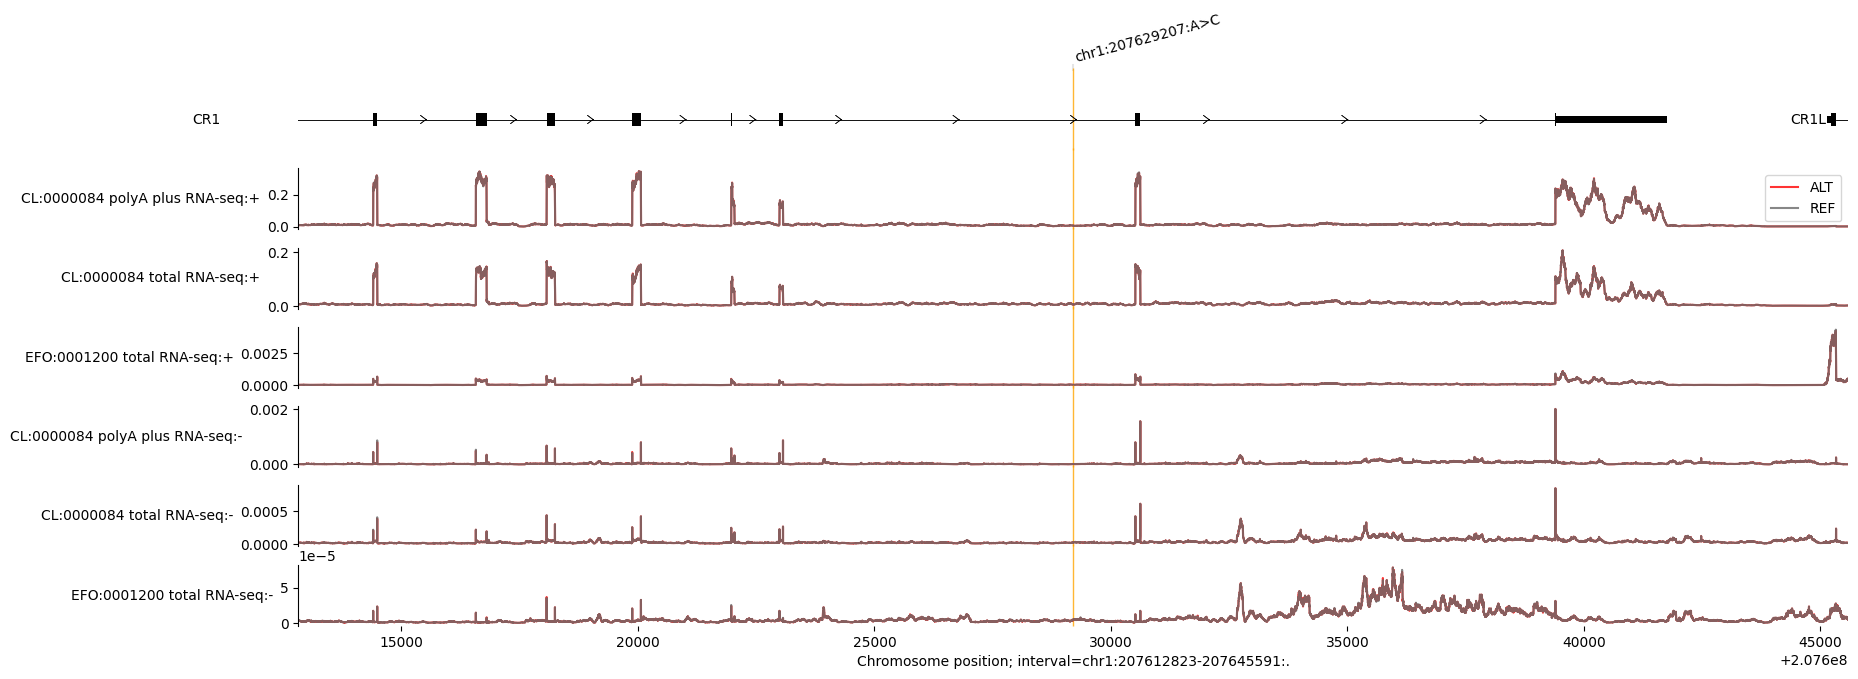

In [13]:
fig = plot_track(ref_track_data, alt_track_data, transcript_extractor, variant)